In [3]:
%pip install "numba==0.62.0rc2"

%pip install -U pip setuptools wheel
%pip install -U numpy scipy scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 53.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 58.5 MB/s  0:00:006m0:00:0100:01
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.44.0
    Uninstalling llvmlite-0.44.0:
      Successfully uninstalled llvmlite-0.44.0━━ 0/2 [llvmlite]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
from scored import SCORED

In [5]:
!pip install --upgrade networkx
import sklearn
import scipy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm.notebook import tqdm
import networkx as nx
from scipy.stats import spearmanr
import numpy as np
import torch
import scanpy as sc
import pandas as pd
from scipy.sparse import csr_matrix
from anndata import AnnData
from typing import Optional, List



Defaulting to user installation because normal site-packages is not writeable


In [6]:
if torch.cuda.is_available():
  dev = "cuda:0"
else:
  dev = "cpu"
device = torch.device(dev)

if torch.cuda.is_available():
   print ("Cuda is available")
   device_id = torch.cuda.current_device()
   gpu_properties = torch.cuda.get_device_properties(device_id)
   print("Found %d GPUs available. Using GPU %d (%s) of compute capability %d.%d with "
          "%.1fGb total memory.\n" %
          (torch.cuda.device_count(),
          device_id,
          gpu_properties.name,
          gpu_properties.major,
          gpu_properties.minor,
          gpu_properties.total_memory / 1e9))
else:
   print ("Cuda is not available")

Cuda is available
Found 1 GPUs available. Using GPU 0 (NVIDIA A100-PCIE-40GB) of compute capability 8.0 with 42.4Gb total memory.



In [7]:
adata_transcript = sc.read_h5ad('/ix1/wchen/Haoran/single_cell_isoform_refinement/pypi_package_demo_data/transcript_raw_8fc.h5ad')

adata_gene = sc.read_h5ad('/ix1/wchen/Haoran/single_cell_isoform_refinement/pypi_package_demo_data/gene_raw_8fc.h5ad')


sc.pp.filter_genes(adata_transcript, min_cells=3)

AnnData object with n_obs × n_vars = 13109 × 65008
    obs: 'pred_celltype_combined', 'condition_time', 'harmony_cluster'
    var: 'transcript_ids', 'gene_ids', 'feature_types', 'gene_names', 'n_cells'

In [8]:
new_matrix = SCORED(
    adata_tr   = adata_transcript,
    device = "cuda"
)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:667: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  data[i] -= regressor[i] @ coeff
/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 65008 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 29982 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 37907 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 37907 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 37907 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 37907 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


...

/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 65000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 65000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 65000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


/ihome/wchen/hah112/.local/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 65000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)



Speedups (CPU / GPU):
   1000 cells: 0.98×
   2000 cells: 1.13×
   3000 cells: 1.38×
   4000 cells: 1.67×
   5000 cells: 2.11×
   6000 cells: 2.18×
   7000 cells: 2.39×
   8000 cells: 2.49×
   9000 cells: 3.24×
  10000 cells: 3.37×
  11000 cells: 4.79×
  12000 cells: 5.06×
  13100 cells: 6.32×


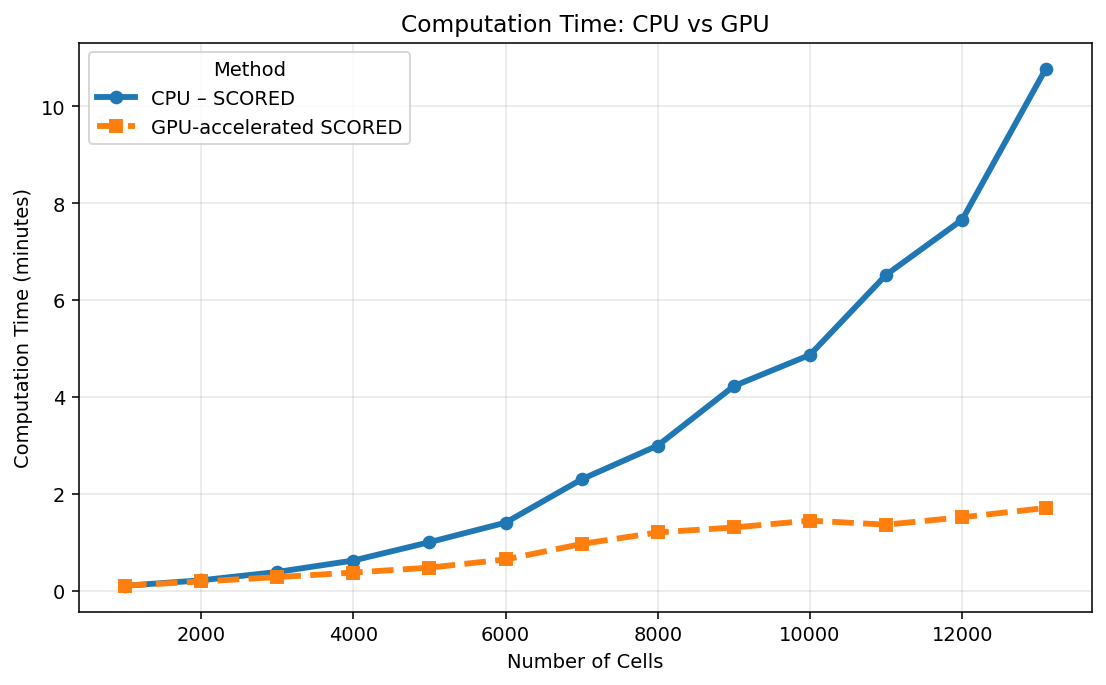


Saved plot to: scored_cpu_vs_gpu.png


In [12]:
# --- Benchmark SCORED: CPU vs GPU -------------------------------------------
# Requirements: SCORED(), adata_transcript (AnnData), matplotlib
# This script:
# 1) samples 1k/2k/3k cells 
# 2) runs SCORED on CPU and GPU (median of 3 runs each, with GPU sync)
# 3) plots runtime (minutes) vs number of cells and prints speedups

import os, gc, time, statistics as stats
import numpy as np
import matplotlib.pyplot as plt

#  reduce CPU timing noise from BLAS threads
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

CELL_SIZES   = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13100]
REPEATS      = 5
RNG_SEED     = 0

def gpu_sync():
    """Synchronize GPU work if torch/cupy is used under the hood (safe no-op otherwise)."""
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            return
    except Exception:
        pass
    try:
        import cupy
        cupy.cuda.Stream.null.synchronize()
    except Exception:
        pass

def clear_gpu_cache():
    """Try to free GPU memory between runs to avoid caching effects."""
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass
    try:
        import cupy
        cupy.get_default_memory_pool().free_all_blocks()
    except Exception:
        pass

def sample_cells(adata, n, seed=0):
    """Randomly sample n cells (obs) from an AnnData-like object."""
    n = min(n, adata.n_obs)
    rng = np.random.default_rng(seed)
    idx = rng.choice(adata.n_obs, n, replace=False)
    try:
        return adata[idx, :].copy()
    except Exception:
        # fallback if .copy() not available
        return adata[idx, :]

def time_run(adata_subset, device, repeats=3):
    times = []
    for _ in range(repeats):
        gc.collect()
        start = time.perf_counter()
        _ = SCORED(adata_tr=adata_subset, device=device)
        if device.lower().startswith("cuda") or device.lower() == "gpu":
            gpu_sync()
            clear_gpu_cache()
        end = time.perf_counter()
        times.append(end - start)
    return stats.median(times)

#  warm-up for GPU (avoids one-time initialization cost skewing results)
try:
    _ = SCORED(adata_tr=sample_cells(adata_transcript, 512, seed=RNG_SEED), device="cuda")
    gpu_sync()
except Exception:
    pass

cpu_times_s = []
gpu_times_s = []

for n in CELL_SIZES:
    sub = sample_cells(adata_transcript, n, seed=RNG_SEED)

    # CPU
    t_cpu = time_run(sub, device="cpu", repeats=REPEATS)
    cpu_times_s.append(t_cpu)

    # GPU 
    try:
        t_gpu = time_run(sub, device="cuda", repeats=REPEATS)
    except Exception as e:
        print(f"[GPU skipped for n={n}] {e}")
        t_gpu = np.nan
    gpu_times_s.append(t_gpu)

# Convert to minutes for plotting
cpu_min = np.array(cpu_times_s) / 60.0
gpu_min = np.array(gpu_times_s) / 60.0

# Print speedups
print("\nSpeedups (CPU / GPU):")
for n, tc, tg in zip(CELL_SIZES, cpu_times_s, gpu_times_s):
    if np.isfinite(tg) and tg > 0:
        print(f"  {n:>5} cells: {tc/tg:.2f}×")
    else:
        print(f"  {n:>5} cells: GPU N/A")

# Plot
plt.figure(figsize=(8,5), dpi=140)
plt.plot(CELL_SIZES, cpu_min, marker='o', linewidth=3, label='CPU – SCORED')
plt.plot(CELL_SIZES, gpu_min, marker='s', linestyle='--', linewidth=3, label='GPU-accelerated SCORED')
plt.title('Computation Time: CPU vs GPU')
plt.xlabel('Number of Cells')
plt.ylabel('Computation Time (minutes)')
plt.legend(title='Method')
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("scored_cpu_vs_gpu.png", bbox_inches="tight")
plt.show()

#print("\nSaved plot to: scored_cpu_vs_gpu.png")
